**Matched Filtering against overlapping GW signals from CBCs**
- Simulate GW data containing two overlapping GW signals from CBCs.
- Calculate their matched filter SNRs.
- Check if matched filtering still works.

> ⚠️ **Warning**: 
> Uncomment and run the following cell to install necessary packages, if running in Google Collab.  
> Restart the runtime after running the cell below. To do so, go to "Runtime" and select "Restart session".


In [1]:
# !pip install pycbc

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from pycbc.waveform import get_td_waveform, get_fd_waveform
from pycbc.psd import aLIGOZeroDetHighPower, AdVDesignSensitivityP1200087
from pycbc.noise.gaussian import frequency_noise_from_psd
from pycbc.filter import matched_filter
from pycbc.detector import Detector
from pycbc.waveform.generator import (FDomainDetFrameGenerator, FDomainCBCGenerator)

%matplotlib inline


/home/abhishek.sharma/miniconda3/envs/gw-env/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [3]:
# Function to whiten a frequency series `freqSeries` colored with `PSD`.
def whiten(freqSeries, PSD):
    
    PSD.data[np.where(PSD.data == 0)[0]] = 10**(-50)
    whiten_strain = (freqSeries / (PSD/freqSeries.delta_t/2) ** 0.5).to_timeseries()
    
    return whiten_strain

In [ ]:
# parameters of the binary...
m1, m2 = 15, 10
s1x, s2x = 0.01, 0.05
s1y, s2y = 0.1, -0.01
s1z, s2z = 0.4, -0.1
distance = 800
ra = 3.44626                                 # Right Ascension
dec = -0.408084                              # Declination
psi = 2.28121                                # Polarization angle
tc = 1464266451
iota= 2.4975 
phic = 0.2
epoch = tc - 40

flow, fhigh = 20, 1024
fsamp = 2*fhigh
duration = 64
delta_f = 1/duration
Nt = fsamp * duration
Nf = int(Nt//2 + 1)

frozenParams= {'approximant' : "IMRPhenomXPHM", 'delta_f' : delta_f, 'f_lower' : flow, 'f_final' : fhigh}

variableParams = ['mass1', 'mass2', 'spin1x', 'spin1y', 'spin1z', 'spin2x', 'spin2y', 'spin2z', \
                  'ra', 'dec', 'tc', 'polarization', 'inclination', 'distance', 'coa_phase']
ifos = ['L1']

generator = FDomainDetFrameGenerator(FDomainCBCGenerator, detectors = ifos, epoch = epoch, \
                                     variable_args = variableParams, **frozenParams)

# Generate the signal in ifos.

binary1_params = {'mass1' : m1, 'mass2' : m2, 'spin1z' : s1z, 'spin2z' : s2z,  \
                  'spin1x': s1x, 'spin2x': s2x, 'spin1y':s1y, 'spin2y':s2y, \
                 'inclination' : iota, 'distance' : distance, 'coa_phase':phic,\
                 'ra': ra, 'dec': dec, 'tc':tc, 'polarization':psi}

tc2 = tc - 0.1
binary2_params = {'mass1' : 8, 'mass2' : 6, 'spin1z' : s1z, 'spin2z' : s2z,  \
                  'spin1x': s1x, 'spin2x': s2x, 'spin1y':s1y, 'spin2y':s2y, \
                 'inclination' : np.pi/3, 'distance' : 150, 'coa_phase':np.pi,\
                 'ra': np.pi/6, 'dec': -np.pi/4, 'tc':tc2, 'polarization':np.pi}

signal1 = generator.generate(**binary1_params)
signal2 = generator.generate(**binary2_params)

# resize if length in frequency domain is not same as Nf.
if len(signal1['L1']) != Nf:
    for ifo in ifos:
        signal1[ifo].resize(Nf)

if len(signal2['L1']) != Nf:
    for ifo in ifos:
        signal2[ifo].resize(Nf)

# Generate psd: Using analytical psds `AdVDesignSensitivityP1200087` for Virgo and `aLIGOZeroDetHighPower` for both LIGO detectors.
psd_V1 = AdVDesignSensitivityP1200087(Nf, delta_f = delta_f, low_freq_cutoff = flow)
psd_L1H1 = aLIGOZeroDetHighPower(Nf, delta_f = delta_f, low_freq_cutoff = flow)

psd = {}
for ifo in ifos:
    if ifo == 'V1':
        psd[ifo] = psd_V1
    else:
        psd[ifo] = psd_L1H1

## Generate data colored with psd.
seed = 0
noise = {}
data_fd = {}

np.random.seed(seed)
for detector in ifos:
    
    print(f'Generating data in frequency domain in {detector}...')
    # Generate Gaussian noise.
    noise[detector] = frequency_noise_from_psd(psd[detector])
    
    # Adding Gaussian noise in signal to generate data.
    data_fd[detector] = signal1[detector] + signal2[detector] + noise[detector]

# Convert FD waveforms into TD waveforms.

data_td = {}
signal1_td = {}
signal2_td = {}

for detector in ifos:
    
    data_td[detector] = data_fd[detector].to_timeseries()
    signal1_td[detector] = signal1[detector].to_timeseries()
    signal2_td[detector] = signal2[detector].to_timeseries()

Generating data in frequency domain in L1...


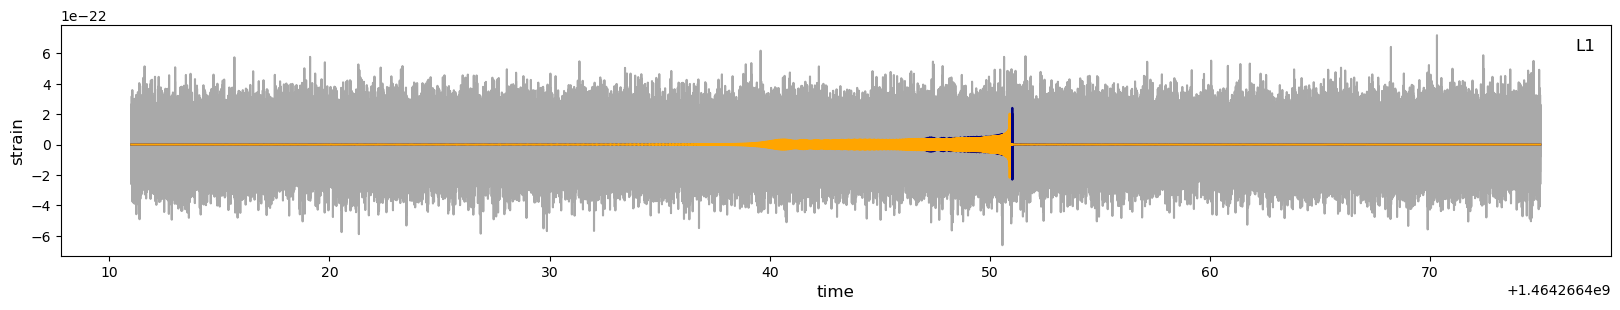

In [5]:
# Plotting whitened data and signal in three detectors.
fig, ax = plt.subplots(1, 1, sharex = True, figsize = (20, 3))
fig.subplots_adjust(hspace = 0)

ax.plot(data_td['L1'].sample_times, data_td['L1'], c = 'darkgray')
ax.plot(signal1_td['L1'].sample_times, signal1_td['L1'], c = 'navy')
ax.plot(signal2_td['L1'].sample_times, signal2_td['L1'], c = 'orange')
# ax.axvline(x = tc, c = 'k', ls = '--')
ax.set_xlabel('time', fontsize = 12)
ax.set_ylabel('strain', fontsize = 12)
ax.set_title('L1', x = 0.99, y = 0.95, pad = -10, fontsize = 12, loc='right')
# ax[0].set_xlim(tc - 0.1, tc + 0.1)

plt.show()

In [6]:
# Whiten the signal and data.
print('Whitening the signal and data.')

whitened_h1_td = {}
whitened_h2_td = {}
whitened_data_td = {}

for detector in ifos:
    
    whitened_h1_td[detector] = whiten(signal1[detector], psd[detector])
    whitened_h2_td[detector] = whiten(signal2[detector], psd[detector])
    whitened_data_td[detector] = whiten(data_fd[detector], psd[detector])

Whitening the signal and data.


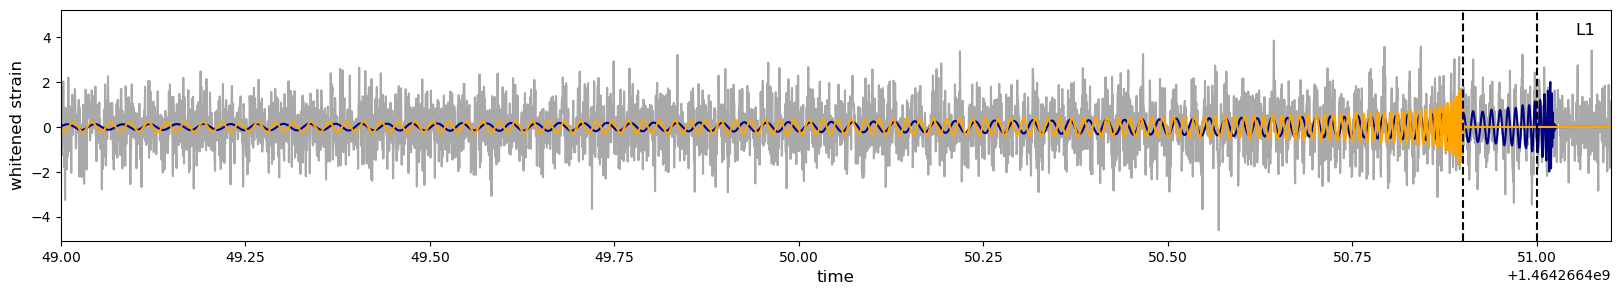

In [7]:
# Plotting whitened data and signal in three detectors.
fig, ax = plt.subplots(1, 1, sharex = True, figsize = (20, 3))
fig.subplots_adjust(hspace = 0)

ax.plot(whitened_data_td['L1'].sample_times, whitened_data_td['L1'], c = 'darkgray')
ax.plot(whitened_h1_td['L1'].sample_times, whitened_h1_td['L1'], c = 'navy')
ax.plot(whitened_h2_td['L1'].sample_times, whitened_h2_td['L1'], c = 'orange')
ax.axvline(x = tc, c = 'k', ls = '--')
ax.axvline(x = tc2, c = 'k', ls = '--')
ax.set_xlabel('time', fontsize = 12)
ax.set_ylabel('whitened strain', fontsize = 12)
ax.set_title('L1', x = 0.99, y = 0.95, pad = -10, fontsize = 12, loc='right')
ax.set_xlim(tc - 2, tc + 0.1)
plt.show()

## Matched filter SNR

In [8]:
# Generate template waveforms
m1, m2, s1z, s2z = 15, 10, 0.4, -0.1

hp1, hc1 = get_fd_waveform(
    approximant='IMRPhenomD',
    mass1=m1,
    mass2=m2,
    spin1z=s1z,
    spin2z=s2z,
    delta_f=delta_f,
    f_lower=flow
)
hp1.resize(Nf)

m1, m2, s1z, s2z = 8, 6, 0.4, -0.1

hp2, hc2 = get_fd_waveform(
    approximant='IMRPhenomD',
    mass1=m1,
    mass2=m2,
    spin1z=s1z,
    spin2z=s2z,
    delta_f=delta_f,
    f_lower=flow
)
hp2.resize(Nf)


In [9]:
matchedFilterSNR2 = {}
network_snr2 = 0
for detector in ifos:
    
    matchedFilterSNR2[detector] = abs(matched_filter(template = hp2, data = data_fd[detector], \
                                                psd=psd[detector], low_frequency_cutoff = flow, high_frequency_cutoff = fhigh))
    print(f'SNR in detector {detector} = {matchedFilterSNR2[detector].max()}')
    network_snr2 += matchedFilterSNR2[detector].max()**2
print(f'Network SNR = {np.sqrt(network_snr2)}')

SNR in detector L1 = 20.177686141857095
Network SNR = 20.177686141857095


In [10]:
snr_template1 = {}
snr_template2 = {}

network_snr1 = 0
network_snr2 = 0
for detector in ifos:
    
    snr_template1[detector] = abs(matched_filter(template = hp1, data = data_fd[detector], \
                                                psd=psd[detector], low_frequency_cutoff = flow, high_frequency_cutoff = fhigh))
    print(f'SNR in detector {detector} with template 1 = {snr_template1[detector].max()}')
    network_snr1 += snr_template1[detector].max()**2

    snr_template2[detector] = abs(matched_filter(template = hp2, data = data_fd[detector], \
                                                psd=psd[detector], low_frequency_cutoff = flow, high_frequency_cutoff = fhigh))
    print(f'SNR in detector {detector} with template 2 = {snr_template2[detector].max()}')
    network_snr2 += snr_template2[detector].max()**2

print(f'Network SNR with template 1 = {np.sqrt(network_snr1)}')
print(f'Network SNR with template 2 = {np.sqrt(network_snr2)}')

SNR in detector L1 with template 1 = 17.592216966609364
SNR in detector L1 with template 2 = 20.177686141857095
Network SNR with template 1 = 17.592216966609364
Network SNR with template 2 = 20.177686141857095


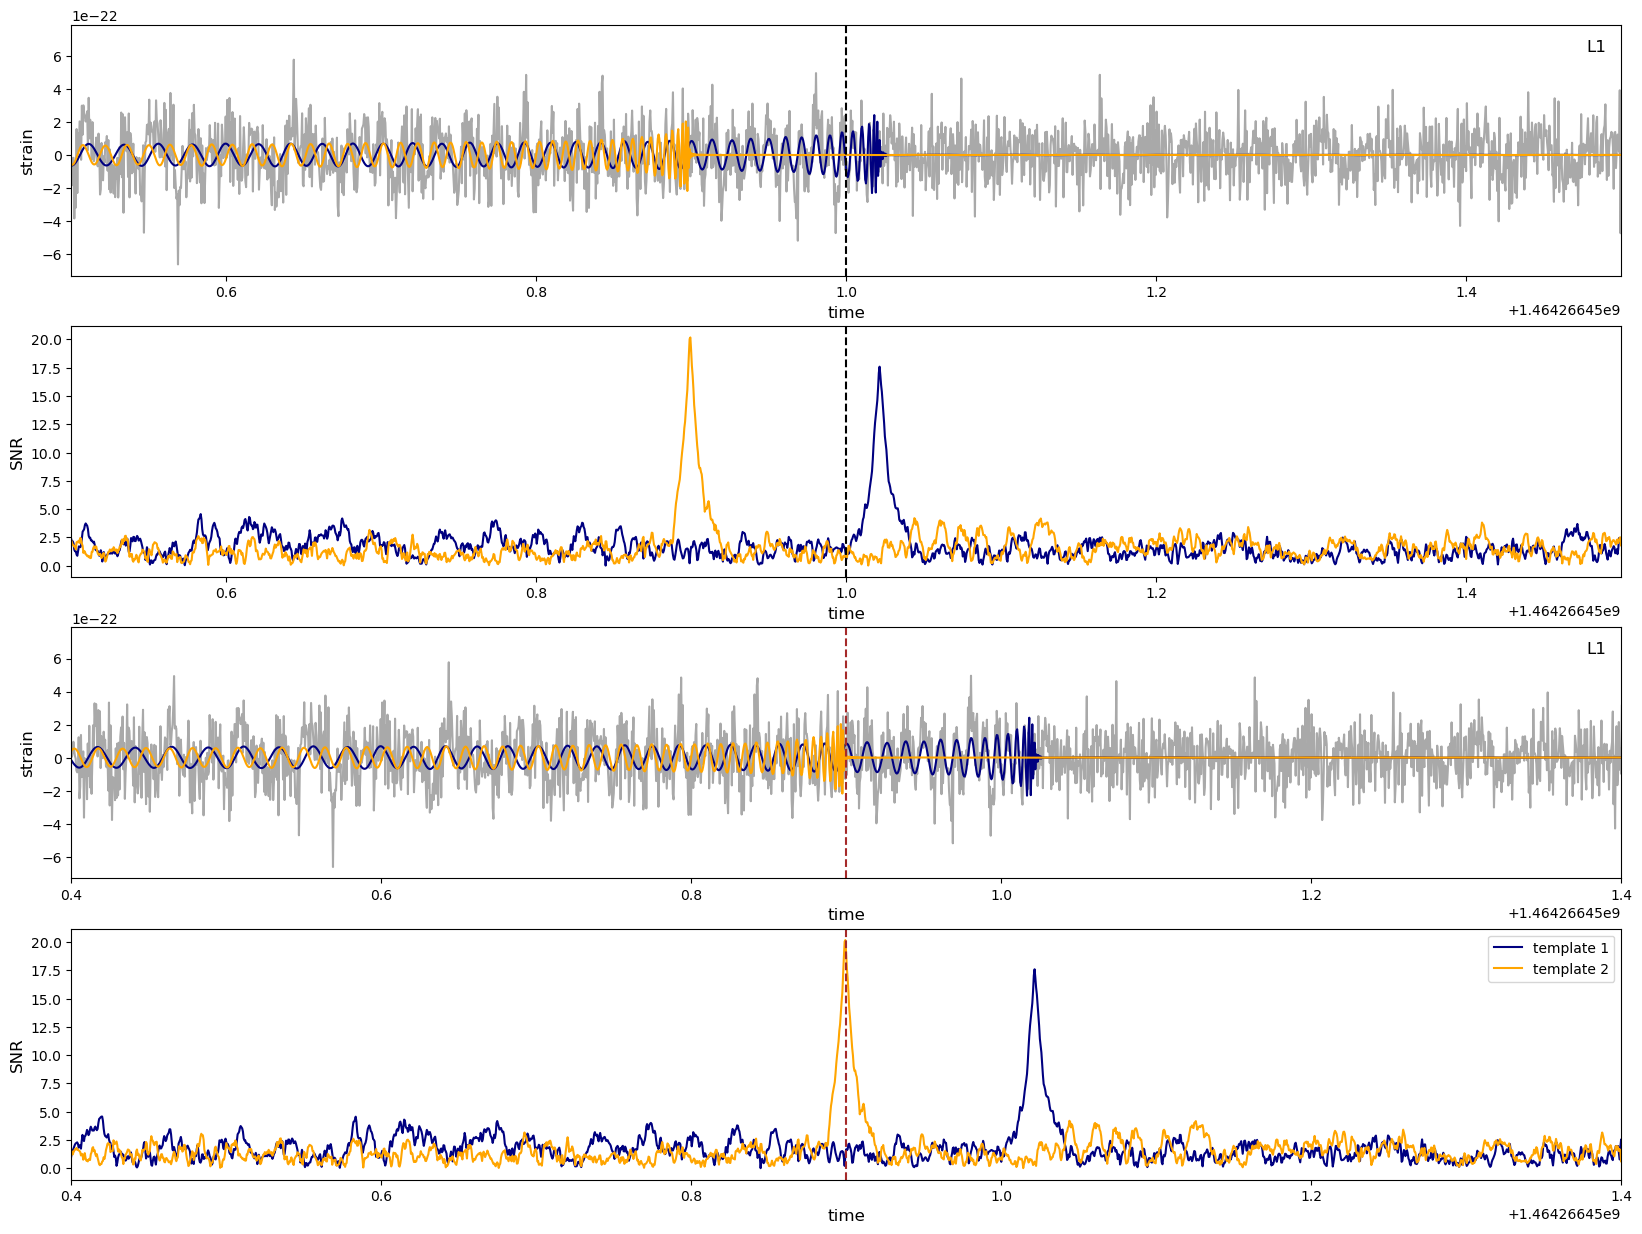

In [11]:
# Plotting whitened data and signal in three detectors.
fig, ax = plt.subplots(4, 1, figsize = (20, 15))
# fig.subplots_adjust(hspace = 0)

ax[0].plot(data_td['L1'].sample_times, data_td['L1'], c = 'darkgray')
ax[0].plot(signal1_td['L1'].sample_times, signal1_td['L1'], c = 'navy')
ax[0].plot(signal2_td['L1'].sample_times, signal2_td['L1'], c = 'orange')
ax[0].axvline(x = tc, ls = '--', color = 'k')
ax[0].set_xlabel('time', fontsize = 12)
ax[0].set_ylabel('strain', fontsize = 12)
# ax[0].set_title('L1', x = 0.99, y = 0.95, pad = -10, fontsize = 12, loc='right')
ax[0].set_xlim(tc - 0.5, tc + 0.5)
ax[0].set_title('L1', x = 0.99, y = 0.95, pad = -10, fontsize = 12, loc='right')

ax[1].plot(snr_template1['L1'].sample_times, snr_template1['L1'], c = 'navy', label = 'template 1')
ax[1].plot(snr_template2['L1'].sample_times, snr_template2['L1'], c = 'orange', label = 'template 2')
ax[1].axvline(x = tc, ls = '--', color= 'k')
ax[1].set_xlabel('time', fontsize = 12)
ax[1].set_ylabel('SNR', fontsize = 12)
ax[1].set_xlim(tc - 0.5, tc + 0.5)

ax[2].plot(data_td['L1'].sample_times, data_td['L1'], c = 'darkgray')
ax[2].plot(signal1_td['L1'].sample_times, signal1_td['L1'], c = 'navy')
ax[2].plot(signal2_td['L1'].sample_times, signal2_td['L1'], c = 'orange')
ax[2].axvline(x = tc2, ls = '--', color = 'brown')
ax[2].set_xlabel('time', fontsize = 12)
ax[2].set_ylabel('strain', fontsize = 12)
# ax[2].set_title('L1', x = 2.99, y = 2.95, pad = -10, fontsize = 12, loc='right')
ax[2].set_xlim(tc2 - 0.5, tc2 + 0.5)
ax[2].set_title('L1', x = 0.99, y = 0.95, pad = -10, fontsize = 12, loc='right')

ax[3].plot(snr_template1['L1'].sample_times, snr_template1['L1'], c = 'navy', label = 'template 1')
ax[3].plot(snr_template2['L1'].sample_times, snr_template2['L1'], c = 'orange', label = 'template 2')
ax[3].axvline(x = tc2, ls = '--', color='brown')
ax[3].set_xlabel('time', fontsize = 12)
ax[3].set_ylabel('SNR', fontsize = 12)
ax[3].set_xlim(tc2 - 0.5, tc2 + 0.5)

plt.legend()
plt.show()

## Exercise
### Check how robust matched filtering is against the closeness of the coalescence times of two GW signals.
- Repeat above exercise with `tc2 = tc - 20s` (two waveforms are well separated - note the SNRs of two signals in this case and compare it with above example), `tc2 = tc - 0.05s` and `tc2 = tc`.